<a href="https://colab.research.google.com/github/shubhiv02-learner/banking-log-anomaly-detection/blob/main/notebooks/SentinelIq_LogisModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install reportlab for PDF generation
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import seaborn as sns
import warnings
import os
import io

warnings.filterwarnings("ignore")
folders = [
    "src",
    "scripts",
    "data/raw",
    "data/processed",
    "outputs",
    "visualizations",
    "models",
    "reports",
    "notebooks",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier # Added this import
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

import xgboost as xgb
import lightgbm as lgb

In [ ]:
import pandas as pd

df = pd.read_csv('outputs/sentineliq_results.csv')

print("Loaded 'outputs/sentineliq_results.csv' into 'df'.")
print(df.columns)
print(df.shape)
print("-"*50)
print(df.head())




Loaded 'outputs/sentineliq_results.csv' into 'df'.
Index(['timestamp', 'service', 'endpoint', 'region', 'latency_ms', 'cpu_usage',
       'memory_usage', 'queue_lag', 'status', 'error_code', 'severity',
       'error_count', 'is_anomaly', 'ewma_latency', 'expected_base_latency',
       'latency_deviation', 'ewma_latency_deviation_for_alert', 'ewma_alert',
       'logdate', 'cusum', 'cusum_alert', 'combined_alert',
       'persistence_score', 'incident_probability', 'priority'],
      dtype='object')
(15000, 25)
--------------------------------------------------
             timestamp            service    endpoint     region  latency_ms  \
0  2026-01-01 00:00:00    fraud-detection    /payment  Singapore         202   
1  2026-01-01 00:00:30  investment-engine  /portfolio        USA         160   
2  2026-01-01 00:01:00    fraud-detection        /kyc    Germany         196   
3  2026-01-01 00:01:30        payment-api   /transfer      India         139   
4  2026-01-01 00:02:00  portfoli

Encode Categorical Features

In [ ]:
# Initializing the LabelEncoder
#Preprocessing data before machine learning, To map text strings to integers like Red- 0, Blue - 1

label_encoder = LabelEncoder()

In [ ]:
df["service"] = label_encoder.fit_transform(df["service"])
df["severity"] = label_encoder.fit_transform(df["severity"])

# Random Forest Feature Selection

In [ ]:
feature_cols = ["service", "latency_ms", "cpu_usage","memory_usage",
                   "queue_lag", "error_count", "severity"]
target_col = "is_anomaly"

# Features (X) and target (y)
X = df[feature_cols].copy()
y = df[target_col]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create a pipeline with RobustScaler and RandomForestClassifier
rf_pipeline = make_pipeline(
    RobustScaler(),
    RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    )
)

# Train the pipeline
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred = rf_pipeline.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Get feature importance from the RandomForestClassifier within the pipeline
# The RandomForestClassifier is the second step in the pipeline (index 1)
rf_model_from_pipeline = rf_pipeline.named_steps['randomforestclassifier']
feature_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model_from_pipeline.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Get anomaly score (probability of being class 1 - anomaly) from the trained Random Forest pipeline
df['rf_anomaly_score'] = rf_pipeline.predict_proba(X)[:, 1]
print("\nAdded 'rf_anomaly_score' to the DataFrame based on Random Forest probabilities.")

# Save outputs
df.to_csv("outputs/sentineliq_results_ml_rf.csv",index=False )

print("Output with metrics saved to outputs/sentineliq_results_ml_rf.csv ")

print("Random Forest detection completed.\n")

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000


Feature Importance:
        Feature  Importance
5   error_count    0.409249
6      severity    0.332558
4     queue_lag    0.247014
1    latency_ms    0.007756
2     cpu_usage    0.002442
3  memory_usage    0.000695
0       service    0.000285

Added 'rf_anomaly_score' to the DataFrame based on Random Forest probabilities.
Output with metrics saved to outputs/sentineliq_results_ml_rf.csv 
Random Forest detection completed.



In [ ]:
import joblib
import os

# Create models directory if it doesn't exist
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# Save the trained pipeline
model_path = os.path.join(models_dir, 'random_forest_pipeline.joblib')
joblib.dump(rf_pipeline, model_path)

print(f"Trained Random Forest pipeline saved to: {model_path}")

Trained Random Forest pipeline saved to: models/random_forest_pipeline.joblib


In [ ]:
print("Shape for X Dataframe: ", X.shape)
print("Columns for X Dataframe: ", X.columns)
print("-"*50)
print("Shape for y Dataframe: ", y.shape)

Shape for X Dataframe:  (15000, 7)
Columns for X Dataframe:  Index(['service', 'latency_ms', 'cpu_usage', 'memory_usage', 'queue_lag',
       'error_count', 'severity'],
      dtype='object')
--------------------------------------------------
Shape for y Dataframe:  (15000,)


<Figure size 1200x800 with 0 Axes>

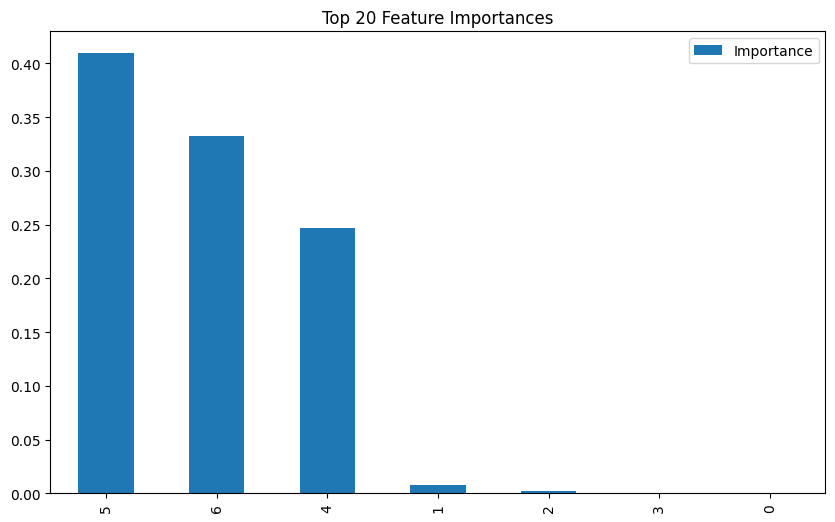

In [ ]:
# Plot feature importances
plt.figure(figsize=(12, 8))
feature_importance.head(20).plot(kind='bar', figsize=(10, 6))
plt.title("Top 20 Feature Importances")
plt.show()

# **Select Only Important Features**

In [ ]:
# Select features with importance greater than a threshold (e.g., 0.01)
important_features = feature_importance[feature_importance['Importance'] > 0.01]['Feature'].values
X = df[important_features]
print("Shape for X Dataframe: ", X.shape)
print("Columns for X Dataframe: ", X.columns)
print("-"*50)
print("Shape for y Dataframe: ", y.shape)
print("-"*50)
print("X Dataframe: ", X.head())

Shape for X Dataframe:  (15000, 3)
Columns for X Dataframe:  Index(['error_count', 'severity', 'queue_lag'], dtype='object')
--------------------------------------------------
Shape for y Dataframe:  (15000,)
--------------------------------------------------
X Dataframe:     error_count  severity  queue_lag
0            0         1          7
1            0         1          6
2            0         1          4
3            0         1          4
4            0         1          6


# **Perform PCA (Principal Component Analysis)**

In [ ]:
# If the number of features is large, PCA can help reduce dimensions
pca = PCA(n_components=2)  # Reducing to 2 components for visualization
X_pca = pca.fit_transform(X)

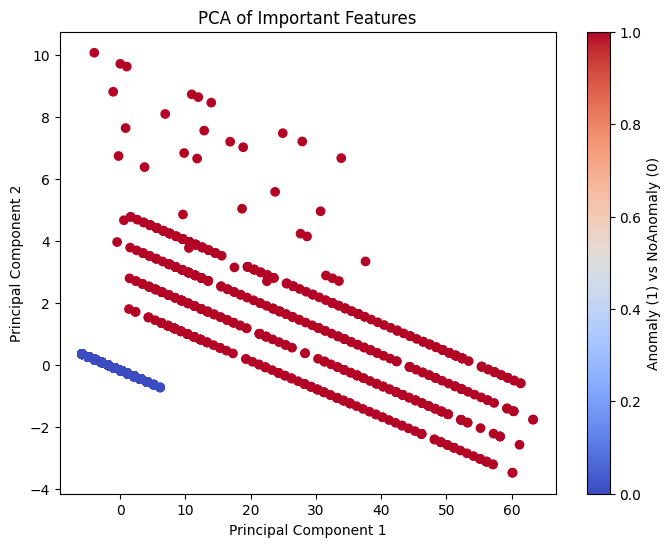

In [ ]:
# Plot PCA results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
plt.title("PCA of Important Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Anomaly (1) vs NoAnomaly (0)')
plt.show()

# **Model Training and Evaluation**


In [ ]:

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': xgb.XGBClassifier(),
    'LightGBM': lgb.LGBMClassifier(),
    'Bagging': BaggingClassifier(),
    'KNN': KNeighborsClassifier()
}


In [ ]:
# Define reduced parameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1],
        'solver': ['liblinear'],
        'penalty': ['l2']
    },
    'Decision Tree': {
        'max_depth': [5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [10],
        'min_samples_split': [2],
        'min_samples_leaf': [1]
    },
    'Gradient Boosting': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5]
    },
    'XGBoost': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [5],
        'subsample': [0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100],
        'learning_rate': [0.1],
        'max_depth': [3, 5],
    },
    'KNN': {
        'n_neighbors': [3],
        'weights': ['uniform', 'distance']
    },
    'Bagging': {
        'n_estimators': [100],
        'max_samples': [0.8, 1.0]
    },
}


In [ ]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
# Initialize an empty dictionary to store results
model_results = {}

# Handle class imbalance by computing class weights for each model that supports it
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("class_weight_dict: ", class_weight_dict)

# Handle SMOTE for class imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Evaluate models with GridSearchCV
for model_name, model in models.items():
    print(f"Training model with GridSearchCV: {model_name}")

    # Get the parameter grid for the model
    param_grid = param_grids[model_name]

    # Modify model to include class weights where applicable
    if model_name in ['Logistic Regression', 'Random Forest']:
        # Assign class weights for models that support it
        if model_name == 'Logistic Regression':
            model = LogisticRegression(class_weight='balanced')
        elif model_name == 'Random Forest':
            model = RandomForestClassifier(class_weight='balanced')


    # Perform GridSearchCV with parallelism
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

    # Fit the model with the best parameters using the resampled data
    grid_search.fit(X_train_smote, y_train_smote)

    # Get the best model and its parameters
    best_model = grid_search.best_estimator_
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")

    # Predict on both train and test sets
    y_train_pred = best_model.predict(X_train_smote)
    y_test_pred = best_model.predict(X_test_scaled)

    # Store the results
    model_results[model_name] = {
        'train_accuracy': best_model.score(X_train_smote, y_train_smote),
        'test_accuracy': best_model.score(X_test_scaled, y_test),
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'classification_report': classification_report(y_test, y_test_pred),
        'roc_auc': roc_auc_score(y_test, best_model.predict_proba(X_test_scaled)[:, 1])
    }

    # Print results after all models are evaluated
    print("\nModel Evaluation Results:")
    print(f"Model: {model_results[model_name]}\n")
    print(f"Train Accuracy: {model_results[model_name]['train_accuracy']:.4f}")
    print(f"Test Accuracy: {model_results[model_name]['test_accuracy']:.4f}")
    print(f"ROC AUC: {model_results[model_name]['roc_auc']:.4f}\n")
    print(f"Classification Report:\n{model_results[model_name]['classification_report']}")
    print("-" * 80)

class_weight_dict:  {0: np.float64(0.5254400560469393), 1: np.float64(10.327022375215146)}
Training model with GridSearchCV: Logistic Regression
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

Model Evaluation Results:
Model: {'train_accuracy': 1.0, 'test_accuracy': 1.0, 'y_test': 11499    0
6475     0
13167    0
862      0
5970     0
        ..
6216     1
3585     0
10023    0
14044    0
12965    0
Name: is_anomaly, Length: 3000, dtype: int64, 'y_test_pred': array([0, 0, 0, ..., 0, 0, 0]), 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00      2867\n           1       1.00      1.00      1.00       133\n\n    accuracy                           1.00      3000\n   macro avg       1.00      1.00      1.00      3000\nweighted avg       1.00      1.00      1.00      3000\n', 'roc_auc': np.float64(1.0)}

Train Ac

# **Plotting the Train Vs Test Accuracy Chart**

----------------------------------------
Model: Logistic Regression
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


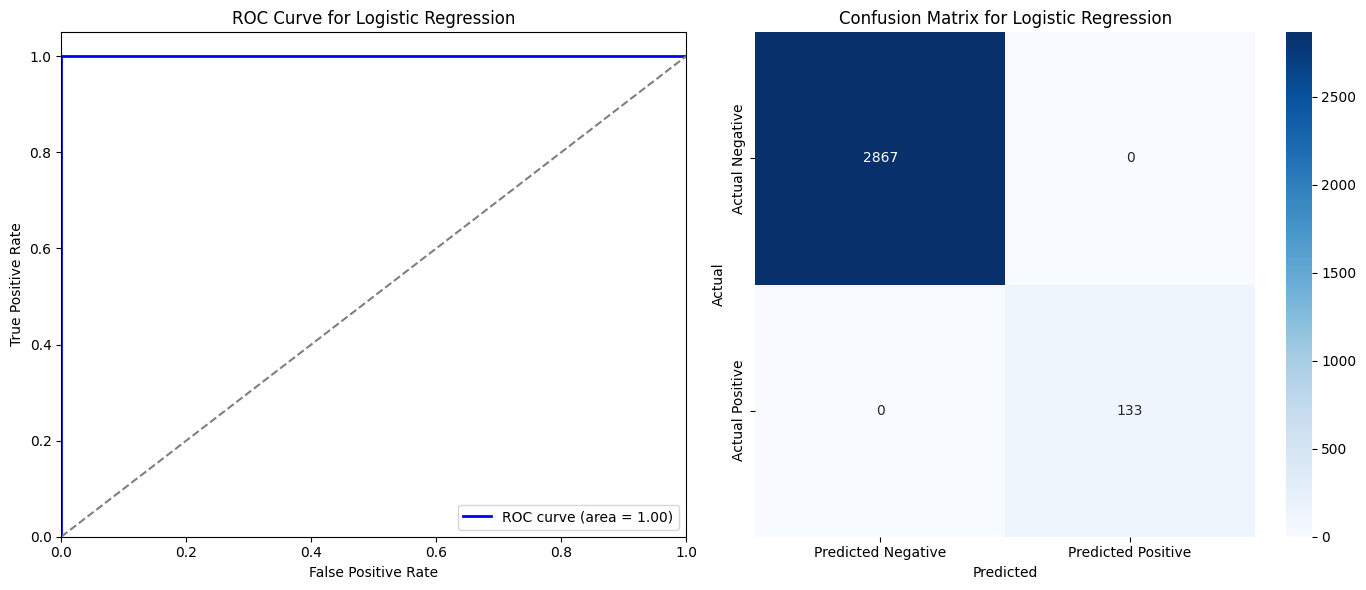

----------------------------------------
Model: Decision Tree
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


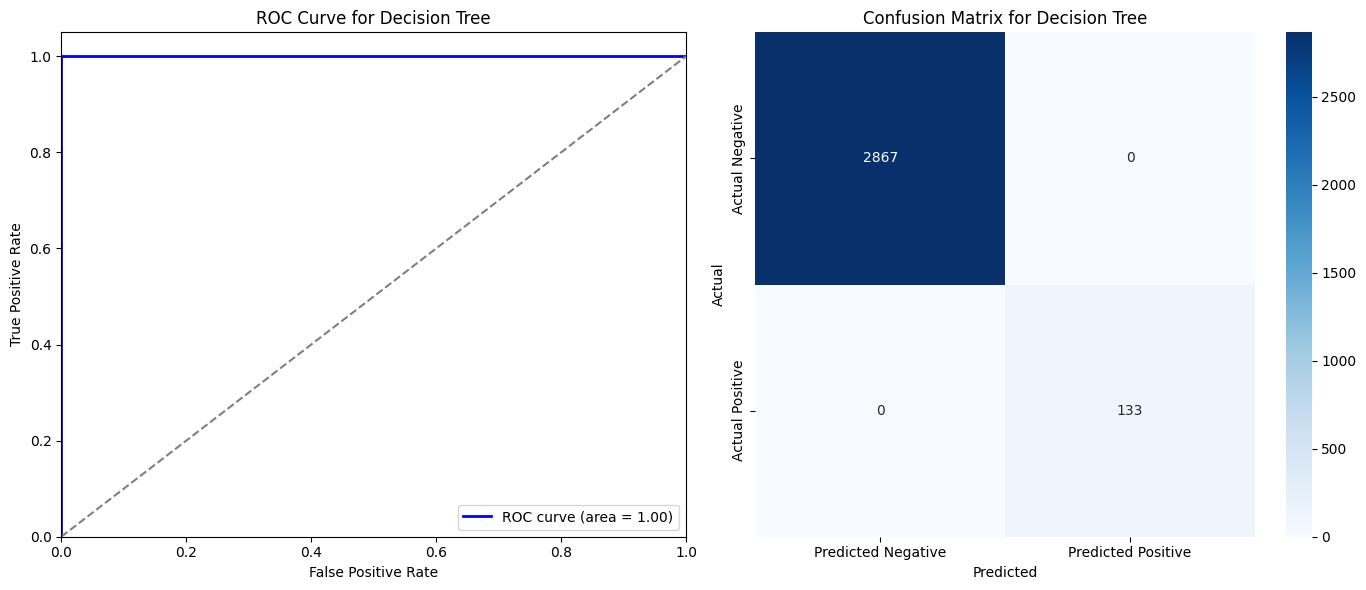

----------------------------------------
Model: Random Forest
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


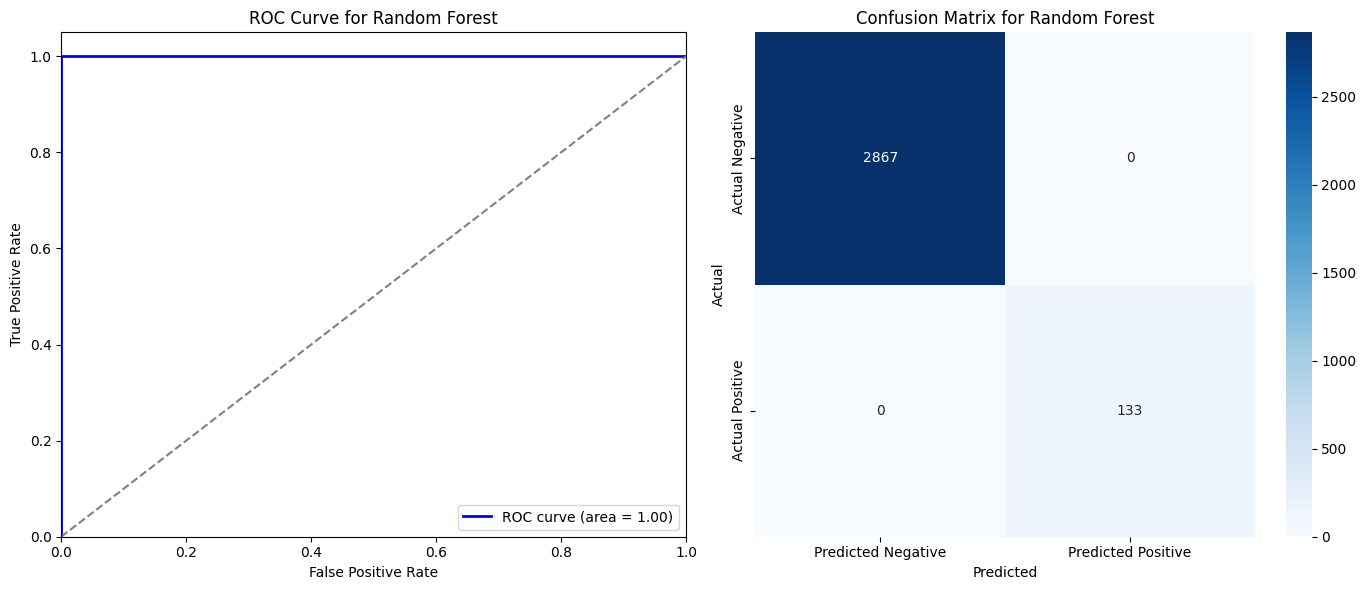

----------------------------------------
Model: Gradient Boosting
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


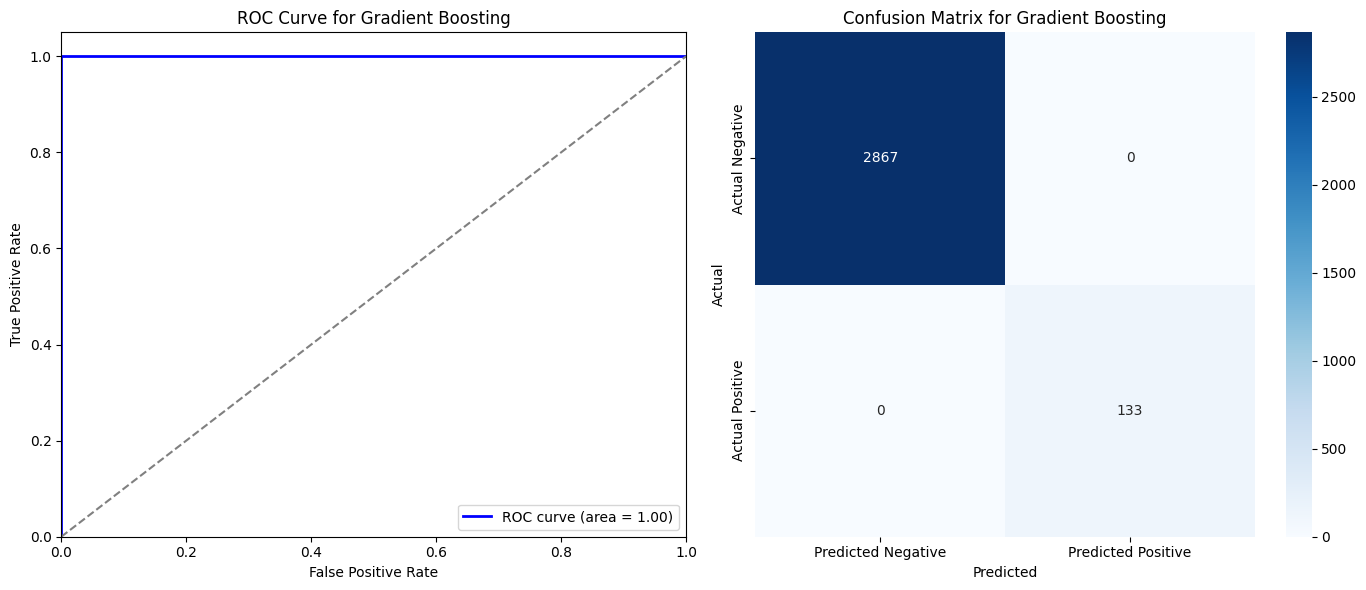

----------------------------------------
Model: XGBoost
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


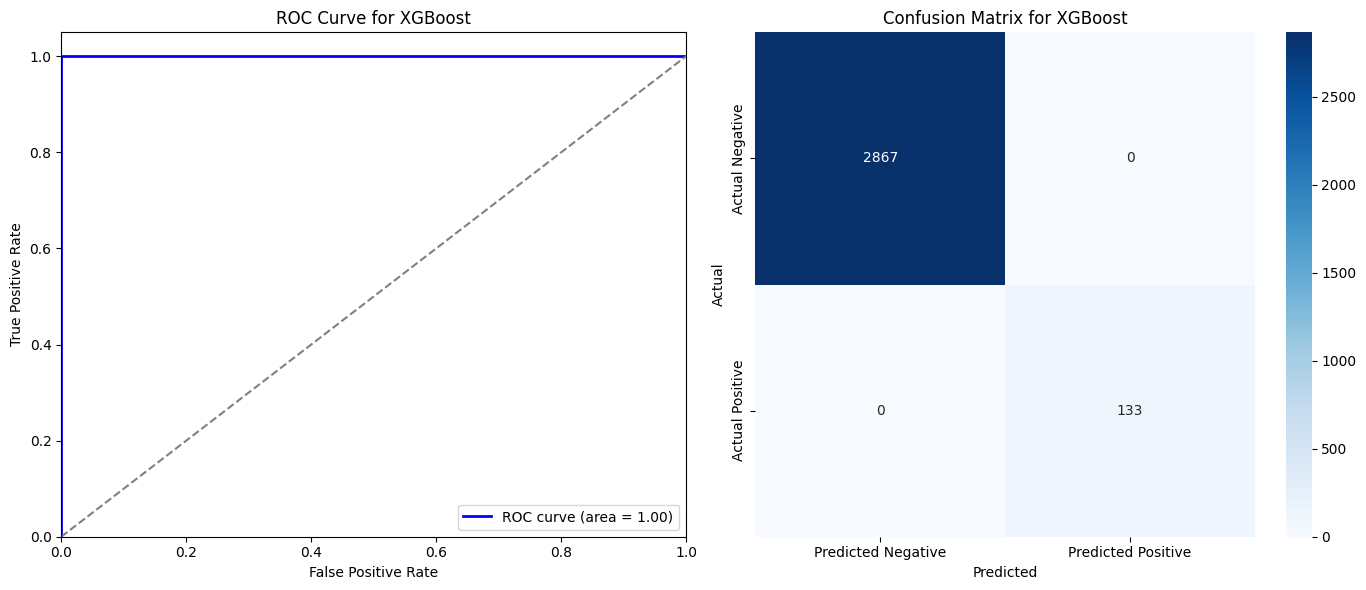

----------------------------------------
Model: LightGBM
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


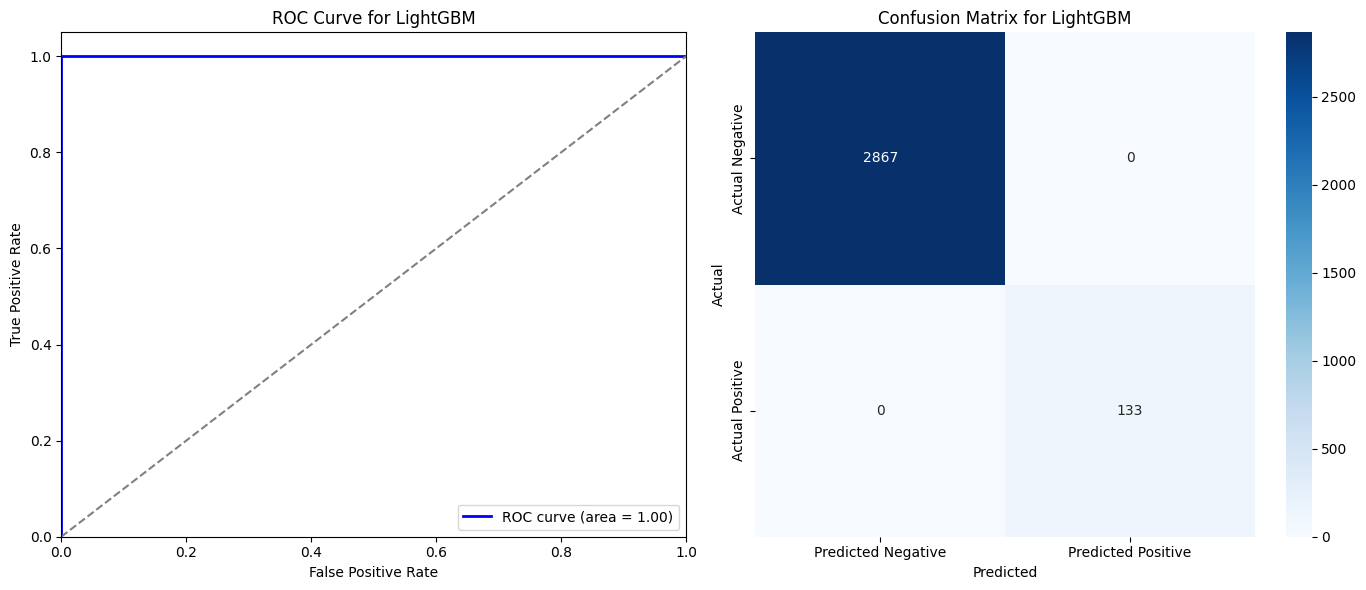

----------------------------------------
Model: Bagging
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


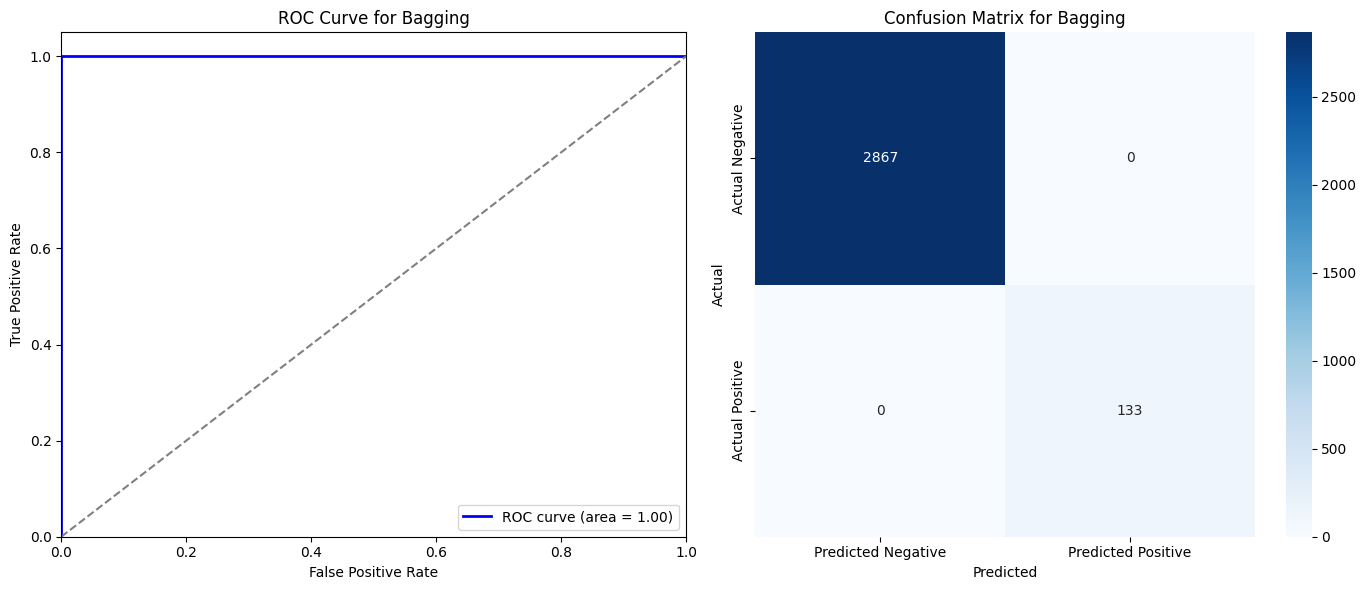

----------------------------------------
Model: KNN
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 1.0000
ROC AUC: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2867
           1       1.00      1.00      1.00       133

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

--------------------------------------------------------------------------------


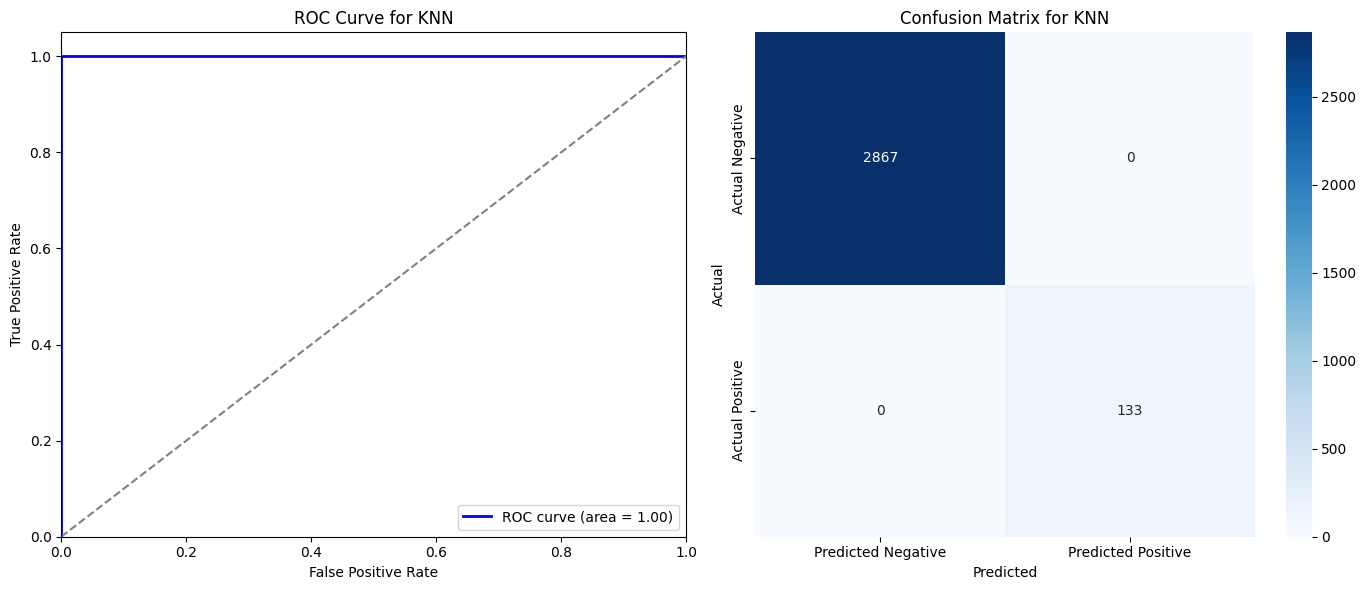

--------------------------------------------------------------------------------


In [ ]:
#import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns
#from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Initialize a list to store results for all models
results_list = []

# Iterate through the models to collect results and plot confusion matrix and ROC curve
for model_name, model in model_results.items():
    # Extract the predicted values and actual values
    y_test_pred = model['y_test_pred']  # Use the predicted labels
    y_test = model['y_test']  # Actual true labels

    # Extract metrics
    train_accuracy = model['train_accuracy']
    test_accuracy = model['test_accuracy']
    roc_auc = model['roc_auc']

    # Classification Report
    clf_report = classification_report(y_test, y_test_pred)

    # Print the model name followed by its evaluation metrics
    print("-" * 40)
    print(f"Model: {model_name}")
    print("-" * 40)
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(clf_report)
    print("-" * 80)  # Separator line for clarity

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_test_pred)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_test_pred)
    roc_auc_value = auc(fpr, tpr)

    # Create subplots: 1 row, 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))  # Width, Height

    # Plot ROC Curve on the first subplot
    ax1.plot(fpr, tpr, color='b', lw=2, label=f'ROC curve (area = {roc_auc_value:.2f})')
    ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve for {model_name}')
    ax1.legend(loc='lower right')

    # Plot Confusion Matrix on the second subplot
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'], ax=ax2)
    ax2.set_title(f'Confusion Matrix for {model_name}')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('Actual')

    # Show both plots
    plt.tight_layout()
    plt.show()

    # Append the results to the list for the DataFrame
    results_list.append({
        'Model': model_name,
        'Train Accuracy': f"{train_accuracy:.4f}",
        'Test Accuracy': f"{test_accuracy:.4f}",
        'ROC AUC': f"{roc_auc:.4f}",
        'Classification Report': clf_report
    })

# Convert results into a DataFrame for better presentation
results_df = pd.DataFrame(results_list)

# Print the summary of results in a tabular format
# print("\nSummary of Model Evaluation Results:")
# print(results_df.to_string(index=False))  # Display as a pretty table
print("-" * 80)


# **Final Conclusion**